In [71]:
# =====================================
# 1. Import Libraries
# =====================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv('../../datasets/Titanic/train.csv')

In [3]:
# =====================================
# 2. Load Dataset
# =====================================
df = pd.read_csv('../../datasets/Titanic/train.csv')

In [4]:
# =====================================
# 3. Initial Data Inspection
# =====================================
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [11]:
df[df["Name"].str.contains("Rose",case=False,na=False)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
72,73,0,2,"Hood, Mr. Ambrose Jr",male,21.0,0,0,S.O.C. 14879,73.50,NaN,S
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.35,NaN,S


In [12]:
df[df["Name"].str.contains("Jack",case=False,na=False)]

# Observation:
# Rose and Jack are fictional characters from the movie Titanic, and they are not present in the actual Titanic dataset. The dataset contains real passenger information, and these names do not correspond to any real passengers on the Titanic.(I thought it was a real story🫠)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
766,767,0,1,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6,NaN,C


In [13]:
df[df["Fare"]==0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,NaN,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0,NaN,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0,NaN,S
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0,NaN,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S


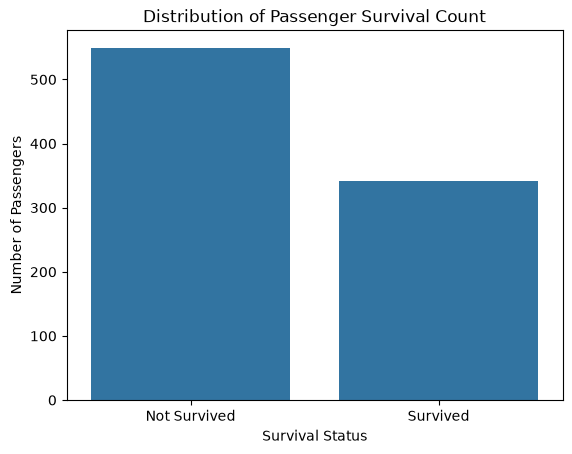

In [14]:
ax=sns.countplot(x='Survived', data=df)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Survived', 'Survived'])
plt.title('Distribution of Passenger Survival Count')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.show()


In [15]:
# ==========================================
# Question:
# Survival rate of each gender?
# ==========================================

df.groupby("Sex")["Survived"].mean()

# Observation:
# The survival rate for females is significantly higher than that for males, indicating that gender had a strong influence on survival.


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [16]:
# ==========================================
# Question:
# How many females and males were onboard?
# ==========================================

df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

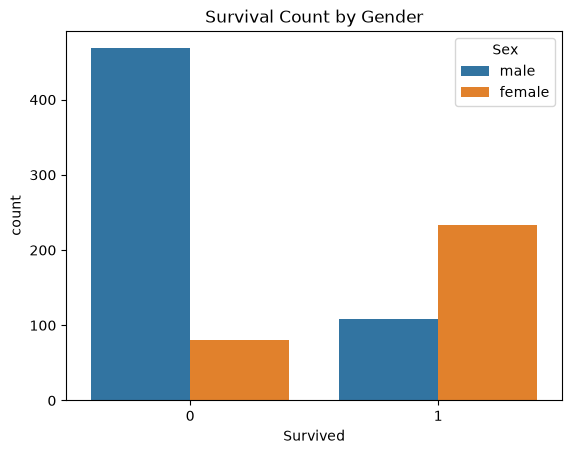

In [17]:
# ==========================================
# Question:
# Does gender affect survival?
# ==========================================

sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Count by Gender')
plt.show()

# Observation:
# The count plot shows that a higher proportion of females survived compared to males, further supporting the observation that gender had a significant impact on survival.


In [18]:
# ==========================================
# Question:
# Survival rate for each Passenger Class?
# ==========================================

df.groupby("Pclass")["Survived"].mean()

# Observation:
# The survival rate for passengers in first class is higher than that for passengers in second and third class, indicating that passenger class had an influence on survival.

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

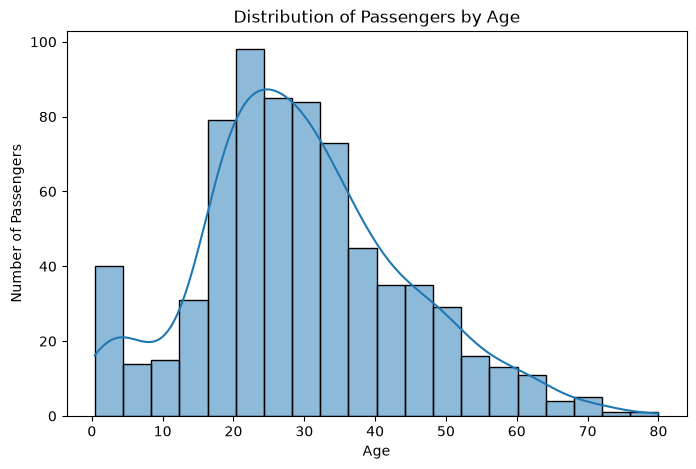

In [19]:
# ==========================================
# Question:
# What is the distribution of passengers by age?
# ==========================================

plt.figure(figsize=(8, 5))

sns.histplot(data=df,x='Age', bins=20 , kde=True)

plt.title('Distribution of Passengers by Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()


# Observation:
# The age distribution is concentrated between 20 and 40 years, indicating that most passengers were young to middle-aged adults. There are relatively fewer children and elderly passengers. The distribution is right-skewed, with a longer tail extending toward higher ages, showing that older passengers were less common.

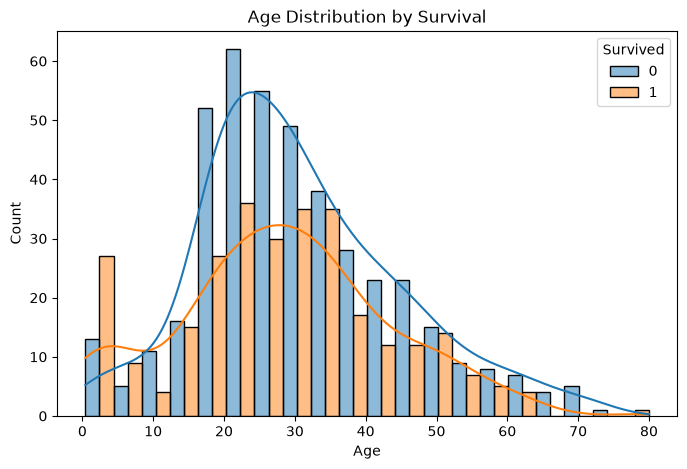

In [20]:
# ==========================================
# Question:
# Does age affect survival?
# ==========================================
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=20,
    multiple="dodge",
    kde=True
)

plt.title("Age Distribution by Survival")
plt.show()


# Observation:
# Most passengers were between 20 and 35 years of age. The number of non-survivors is higher than survivors in this age range. Young children appear to have a relatively higher proportion of survivors compared to some adult age groups, while there are relatively few elderly passengers in the dataset. However, this visualization compares counts, so it does not by itself prove that a particular age group had a higher survival rate.


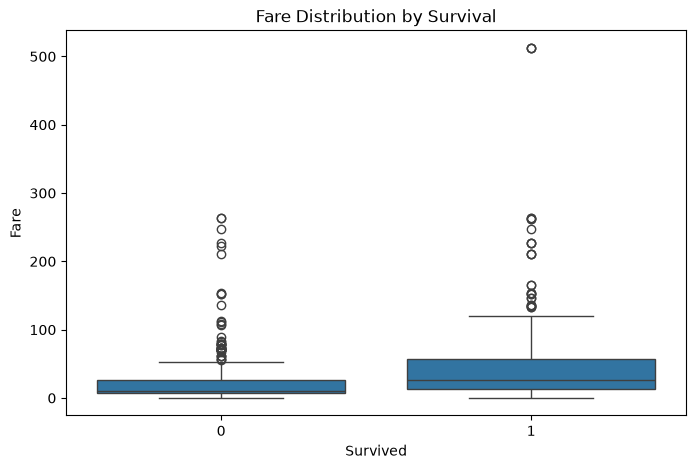

In [21]:
# ==========================================
# Question:
# Does fare affect survival?
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(data=df , x='Survived', y='Fare' )
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()


# Observation:
# Passengers who survived generally paid higher fares than those who did not survive. The higher median fare and higher overall fare distribution among survivors suggest that fare is associated with survival.

In [22]:
# Question:
# Does family size affect survival?

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [23]:
df.groupby("FamilySize")["Survived"].mean()


# Observation:
# The survival rate does not increase consistently with family size. Passengers travelling in small to medium-sized families show the highest survival rates, while passengers travelling alone and those in very large families have comparatively lower survival rates. This suggests that family size may be an important predictive feature.

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [24]:
# ==========================================
# Data Cleaning
# ==========================================

In [25]:
df["Age"]=df["Age"].fillna(df["Age"].median())

In [26]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [27]:
df=df.drop(columns=['Cabin'])

In [28]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
dtype: int64

In [29]:
# Question:
# What is the correlation between features and survival?

corr = df.corr(numeric_only=True)
corr


# Observation:
# Pclass has the strongest negative correlation with Survived (-0.338), suggesting that passengers in higher-numbered classes had lower survival rates.
# Fare has a moderate positive correlation with Survived (0.257), suggesting that passengers paying higher fares tended to have higher survival.
# Age has a weak negative correlation with Survived (-0.077), indicating little linear relationship.
# FamilySize has almost no linear correlation with Survived (0.017), although our earlier group-based analysis revealed that survival varies across different family sizes.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
FamilySize,-0.040143,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


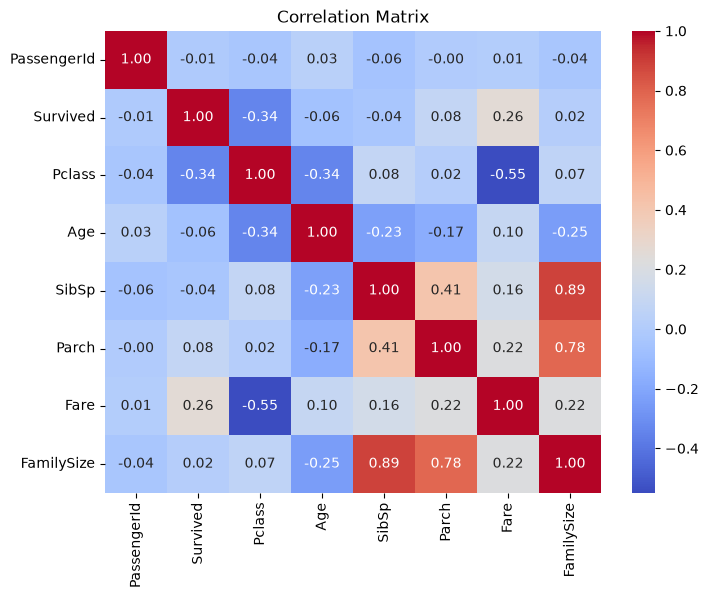

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [31]:
# Outliers Detection for Fare Feature


# Question:
# What is the interquartile range (IQR) of the Fare feature?

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)


Q1: 7.9104
Q3: 31.0
IQR: 23.0896


In [32]:
# Question:
# What are the lower and upper bounds for detecting outliers in the Fare feature?

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -26.724
Upper bound: 65.6344


In [33]:
# Question:
# How many outliers are there in the Fare feature?

fare_outliers = df[df["Fare"] > upper_bound]

print("Number of Fare outliers:", len(fare_outliers))

Number of Fare outliers: 116


In [34]:
# Question:
# What are the details of the passenger with high Fare?

fare_outliers[["PassengerId", "Pclass", "Fare"]].sort_values("Fare", ascending=False)

,PassengerId,Pclass,Fare
679,680,1,512.3292
258,259,1,512.3292
737,738,1,512.3292
341,342,1,263.0000
438,439,1,263.0000
...,...,...,...
324,325,3,69.5500
369,370,1,69.3000
641,642,1,69.3000
151,152,1,66.6000


In [35]:
fare_outliers[["PassengerId", "Pclass", "Fare","Survived"]]

,PassengerId,Pclass,Fare,Survived
1,2,1,71.2833,1
27,28,1,263.0000,0
31,32,1,146.5208,1
34,35,1,82.1708,0
52,53,1,76.7292,1
...,...,...,...,...
846,847,3,69.5500,0
849,850,1,89.1042,1
856,857,1,164.8667,1
863,864,3,69.5500,0


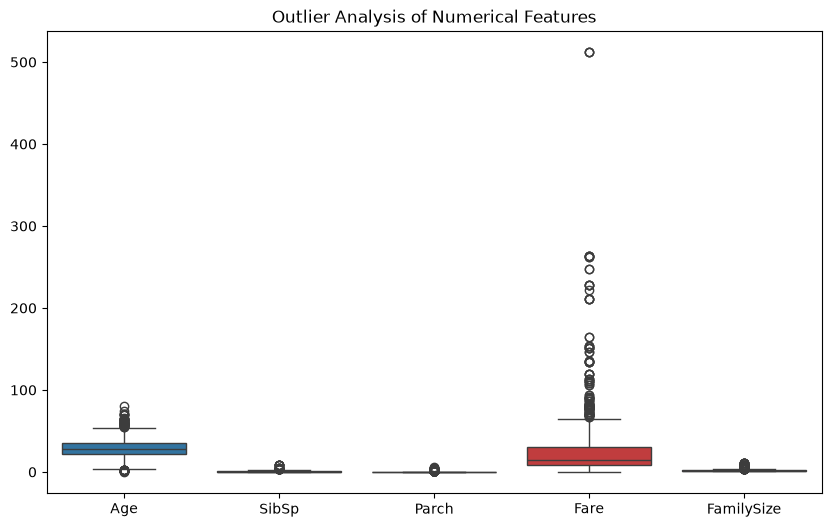

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["Age", "SibSp", "Parch", "Fare", "FamilySize"]])

plt.title("Outlier Analysis of Numerical Features")
plt.show()

In [37]:
# Feature Selection

In [38]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize'],
      dtype='str')

In [39]:
df["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: str

In [40]:
# Extraction of Title from Name
df["Name"].str.split(",")

0                             [Braund,  Mr. Owen Harris]
1      [Cumings,  Mrs. John Bradley (Florence Briggs ...
2                              [Heikkinen,  Miss. Laina]
3        [Futrelle,  Mrs. Jacques Heath (Lily May Peel)]
4                            [Allen,  Mr. William Henry]
                             ...                        
886                             [Montvila,  Rev. Juozas]
887                      [Graham,  Miss. Margaret Edith]
888          [Johnston,  Miss. Catherine Helen "Carrie"]
889                             [Behr,  Mr. Karl Howell]
890                               [Dooley,  Mr. Patrick]
Name: Name, Length: 891, dtype: object

In [41]:
df["Title"] = df["Name"].str.split(",").str[1].str.split(".").str[0].str.strip()

In [42]:
df[["Name","Title"]].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [43]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [44]:
common_titles=["Mr", "Mrs", "Miss", "Master"]
df["TitleGroup"]=df["Title"].where(df["Title"].isin(common_titles),"Rare")

In [45]:
df["TitleGroup"].value_counts()

TitleGroup
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [46]:
df[["Name", "Title", "TitleGroup"]].head(10)

,Name,Title,TitleGroup
0,"Braund, Mr. Owen Harris",Mr,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,Mrs
2,"Heikkinen, Miss. Laina",Miss,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,Mrs
4,"Allen, Mr. William Henry",Mr,Mr
5,"Moran, Mr. James",Mr,Mr
6,"McCarthy, Mr. Timothy J",Mr,Mr
7,"Palsson, Master. Gosta Leonard",Master,Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,Mrs


In [47]:
df=df.drop(columns=['Name', 'Title'])

In [48]:
# Extract ticket group size

df["Ticket"].value_counts().head(10)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
Name: count, dtype: int64

In [49]:
df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("count")

In [50]:
df[["Ticket", "TicketGroupSize"]].head(10)

,Ticket,TicketGroupSize
0,A/5 21171,1
1,PC 17599,1
2,STON/O2. 3101282,1
3,113803,2
4,373450,1
5,330877,1
6,17463,1
7,349909,4
8,347742,3
9,237736,2


In [51]:
df=df.drop(columns=["Ticket","PassengerId"])

In [52]:
# Encoding categorical values 

df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [53]:
df["Sex"]=df["Sex"].map({"male":0,"female":1})

In [54]:
# Encoding Embarked column using one-hot encoding
df = pd.get_dummies(df,columns=["Embarked"],dtype=int)

In [55]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,TitleGroup,TicketGroupSize,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,Mr,1,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,Mrs,1,1,0,0
2,1,3,1,26.0,0,0,7.9250,1,Miss,1,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,Mrs,2,0,0,1
4,0,3,0,35.0,0,0,8.0500,1,Mr,1,0,0,1


In [56]:
# Encoding TitleGroup column using one-hot encoding

df = pd.get_dummies(df,columns=["TitleGroup"],dtype=int)

In [57]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,TicketGroupSize,Embarked_C,Embarked_Q,Embarked_S,TitleGroup_Master,TitleGroup_Miss,TitleGroup_Mr,TitleGroup_Mrs,TitleGroup_Rare
0,0,3,0,22.0,1,0,7.2500,2,1,0,0,1,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,2,1,1,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,1,1,0,0,1,0,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,2,2,0,0,1,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,1,1,0,0,1,0,0,1,0,0


In [58]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'TicketGroupSize', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'TitleGroup_Master', 'TitleGroup_Miss', 'TitleGroup_Mr',
       'TitleGroup_Mrs', 'TitleGroup_Rare'],
      dtype='str')

In [59]:
df = df.drop(columns=["SibSp", "Parch"])

In [60]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'FamilySize',
       'TicketGroupSize', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'TitleGroup_Master', 'TitleGroup_Miss', 'TitleGroup_Mr',
       'TitleGroup_Mrs', 'TitleGroup_Rare'],
      dtype='str')

# Preparing Data for Machine Learning

In [61]:
x=df.drop(columns=["Survived"])
y=df["Survived"]

In [62]:
print(x.shape)
print(y.shape)

(891, 14)
(891,)


In [63]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42, stratify=y)

In [64]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 14)
(179, 14)
(712,)
(179,)


In [65]:
model = LogisticRegression(max_iter=1000)

In [66]:
model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [68]:
y_pred = model.predict(x_test)

In [69]:
print(y_pred[:15])

[0 0 0 0 1 1 1 0 0 0 0 0 1 0 0]


In [70]:
print(y_test.values[:15])

[0 0 1 0 1 1 1 0 0 0 0 0 1 0 0]


In [72]:
# Calculating accuracy of the model

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8379888268156425
